<a href="https://colab.research.google.com/github/Anubhav-maurya6386/INTRANSHIP_TASK/blob/main/ImplementKNNClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset

In [2]:
data = pd.read_csv("/content/1) iris.csv")

print(data.head())
print(data.shape)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)


# Define Features and Target

In [3]:
X = data.drop("species", axis=1)
y = data["species"]

# Split Dataset (Training & Testing)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train KNN Model

In [5]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

# Make Predictions

In [6]:
y_pred = knn.predict(X_test)

# Evaluate Model

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


# Confusion Matrix

In [8]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


# Precision, Recall, F1 Score

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Compare Different K Values

In [10]:
accuracy_scores = []

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracy_scores.append(acc)

print(accuracy_scores)

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9666666666666667, 1.0, 1.0, 1.0]


# Visualization of K vs Accuracy

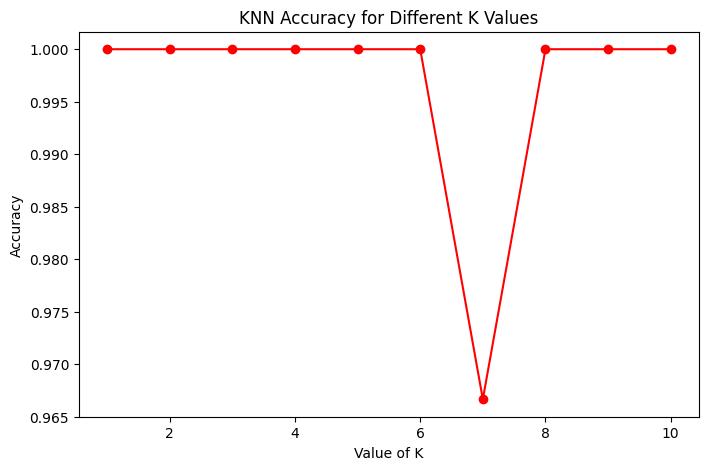

In [11]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), accuracy_scores, marker='o', color='red')

plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")

plt.show()